# Geocalibration ZL048 and ZR048

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import plotly.express as px
from plotly.subplots import make_subplots
from typing import List

In [2]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

Here we load the data for ZL048 and ZR048

In [4]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

# outlier removal
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  outlier_removed = True
  
zr = zr[zr["fmc"]>1590]
zr = zr[zr["fmc"]<2000].reset_index(drop=True)

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	68


## Rotation $R^m_c$ Fitting

For each FMC we compute its median quaternion value and use that as a prediction. Should an FMC value not be specified in the data, we would use the median value of the nearest FMC

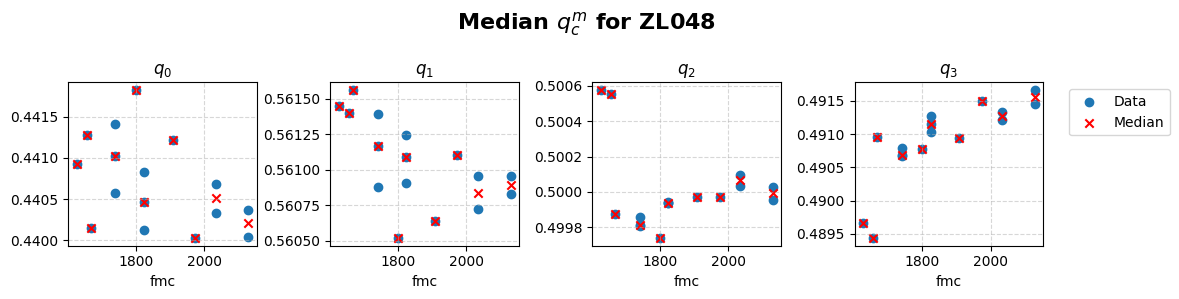

In [55]:
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
data_ = zl.copy()

q_mc_all_left = {fmc:[] for fmc in data_["fmc"].unique()}
for fmc in data_["fmc"].unique():
  fmc_data = data_[data_["fmc"]==fmc].copy().reset_index(drop=True)

  for i in range(fmc_data.shape[0]):
    # Hr
    hr = get_H_r_data(i, fmc_data)
    # Hc^{-1}
    fl, b1, b2, cx, cy = fmc_data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
    # R^r'_m
    R_rpm = get_R_rpm(i, fmc_data)
    # compute R^m_c
    R_mc = (R_rrp @ R_rpm).T @ hr @ hc_inv
    rot_mc = R.from_matrix(R_mc)

    q_mc_all_left[fmc].append(rot_mc.as_quat(canonical=True))

# compute median for that FMC
q_mc_median_left = {fmc:np.median(np.array(q_mc_all_left[fmc]), axis=0) for fmc in q_mc_all_left.keys()}

# plot the figure
fig, ax = plt.subplots(1,4, figsize=(12, 3))
fmc_list = [fmc for fmc in q_mc_all_left.keys() for _ in range(len(q_mc_all_left[fmc]))]
for i in range(4):
  q_i = [q[i] for fmc in q_mc_all_left.keys() for q in q_mc_all_left[fmc]]
  ax[i].scatter(fmc_list, q_i, label="Data")
  ax[i].scatter(q_mc_median_left.keys(), [q[i] for q in q_mc_median_left.values()], 
                marker='x', color='red', label="Median")
  ax[i].set_xlabel("fmc")
  ax[i].set_title(f"$q_{i}$")
  ax[i].grid(linestyle="--", alpha=0.5)

ax[3].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("Median $q^m_c$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

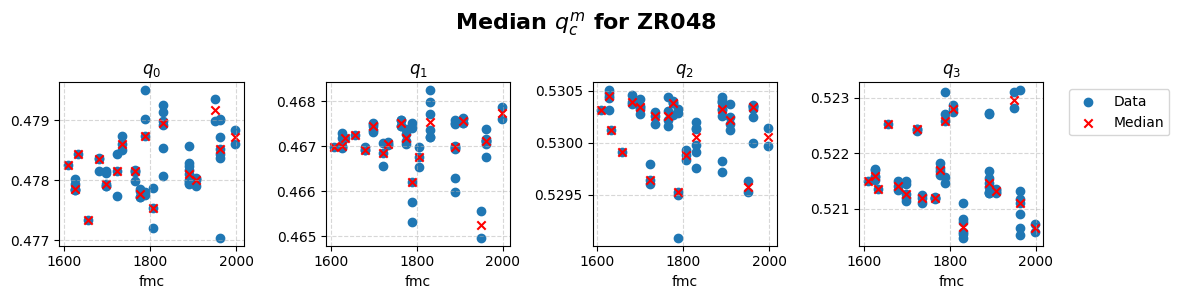

In [64]:
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
data_ = zr.copy()

q_mc_all_right = {fmc:[] for fmc in data_["fmc"].unique()}
for fmc in data_["fmc"].unique():
  fmc_data = data_[data_["fmc"]==fmc].copy().reset_index(drop=True)

  for i in range(fmc_data.shape[0]):
    # Hr
    hr = get_H_r_data(i, fmc_data)
    # Hc^{-1}
    fl, b1, b2, cx, cy = fmc_data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
    # R^r'_m
    R_rpm = get_R_rpm(i, fmc_data)
    # compute R^m_c
    R_mc = (R_rrp @ R_rpm).T @ hr @ hc_inv
    rot_mc = R.from_matrix(R_mc)

    q_mc_all_right[fmc].append(rot_mc.as_quat(canonical=True))

# compute median for that FMC
q_mc_median_right = {fmc:np.median(np.array(q_mc_all_right[fmc]), axis=0) for fmc in q_mc_all_right.keys()}

# plot the figure
fig, ax = plt.subplots(1,4, figsize=(12, 3))
fmc_list = [fmc for fmc in q_mc_all_right.keys() for _ in range(len(q_mc_all_right[fmc]))]
for i in range(4):
  q_i = [q[i] for fmc in q_mc_all_right.keys() for q in q_mc_all_right[fmc]]
  ax[i].scatter(fmc_list, q_i, label="Data")
  ax[i].scatter(q_mc_median_right.keys(), [q[i] for q in q_mc_median_right.values()], 
                marker='x', color='red', label="Median")
  ax[i].set_xlabel("fmc")
  ax[i].set_title(f"$q_{i}$")
  ax[i].grid(linestyle="--", alpha=0.5)

ax[3].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("Median $q^m_c$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

plot the fits for $R^m_c$

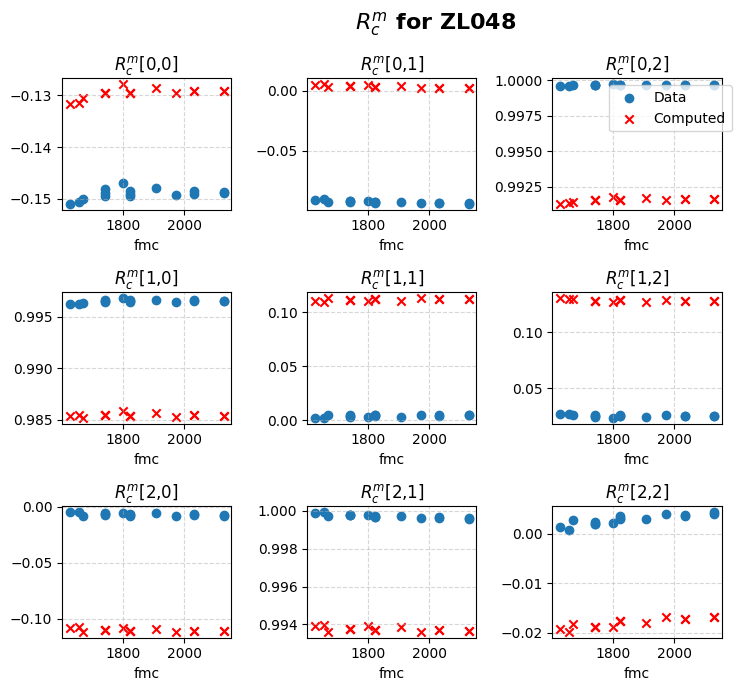

In [69]:
R_mc_data_left, R_mc_comp_left = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zl.shape[0]):
  # Compute R_mc from data assuming R_rrp values
  hr = get_H_r_data(i, zl)

  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  
  R_rpm = get_R_rpm(i, zl)

  R_mc_data_left.append((R_rrp @ R_rpm).T @ hr @ hc_inv)
  

  # compute Hr using the median q_mc value
  f = zl["fmc"][i]
  R_mc = R.from_quat(q_mc_median_left[f]).as_matrix()
  
  R_mc_comp_left.append(R_mc)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [R_mc[i][j] for R_mc in R_mc_data_left], label="Data")
    ax[i,j].scatter(zl["fmc"], [R_mc[i][j] for R_mc in R_mc_comp_left],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$R^m_c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$R^m_c$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()


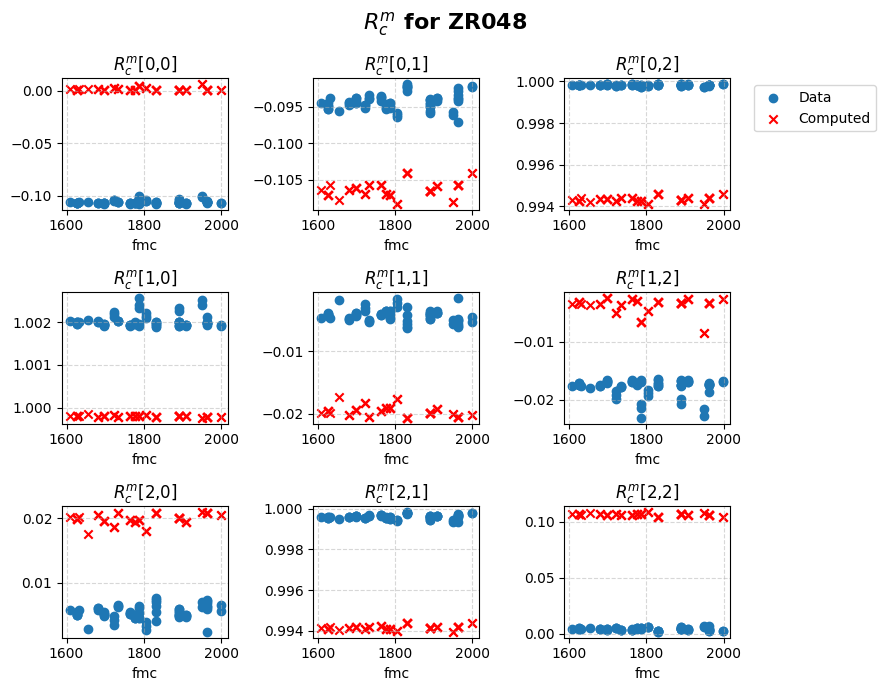

In [72]:
R_mc_data_right, R_mc_comp_right = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zr.shape[0]):
  # Compute R_mc from data assuming R_rrp values
  hr = get_H_r_data(i, zr)

  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  
  R_rpm = get_R_rpm(i, zr)

  R_mc_data_right.append((R_rrp @ R_rpm).T @ hr @ hc_inv)
  

  # compute Hr using the median q_mc value
  f = zr["fmc"][i]
  R_mc = R.from_quat(q_mc_median_right[f]).as_matrix()
  
  R_mc_comp_right.append(R_mc)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [R_mc[i][j] for R_mc in R_mc_data_right], label="Data")
    ax[i,j].scatter(zr["fmc"], [R_mc[i][j] for R_mc in R_mc_comp_right],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$R^m_c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$R^m_c$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()


Plot the fits for $R^r_c$

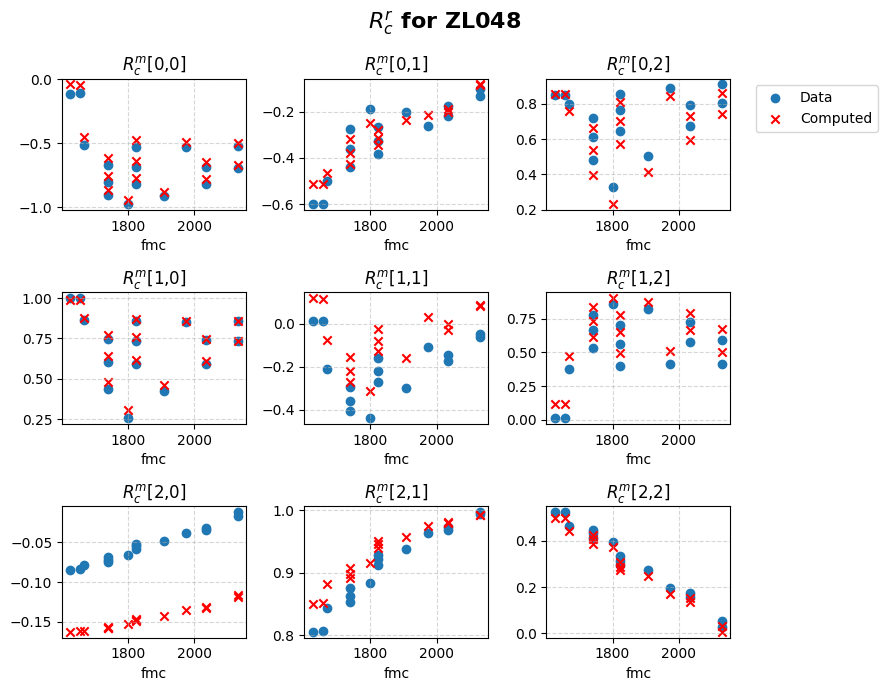

In [74]:
R_rc_data_left, R_rc_comp_left = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zl.shape[0]):
  # Compute R_mc from data assuming R_rrp values
  hr = get_H_r_data(i, zl)

  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  
 
  R_rc_data_left.append(hr @ hc_inv)
  

  # compute Hr using the median q_mc value
  R_rpm = get_R_rpm(i, zl)

  f = zl["fmc"][i]
  R_mc = R.from_quat(q_mc_median_left[f]).as_matrix()
  
  R_rc_comp_left.append(R_rrp @ R_rpm @ R_mc)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [R_mc[i][j] for R_mc in R_rc_data_left], label="Data")
    ax[i,j].scatter(zl["fmc"], [R_mc[i][j] for R_mc in R_rc_comp_left],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$R^r_c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$R^r_c$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

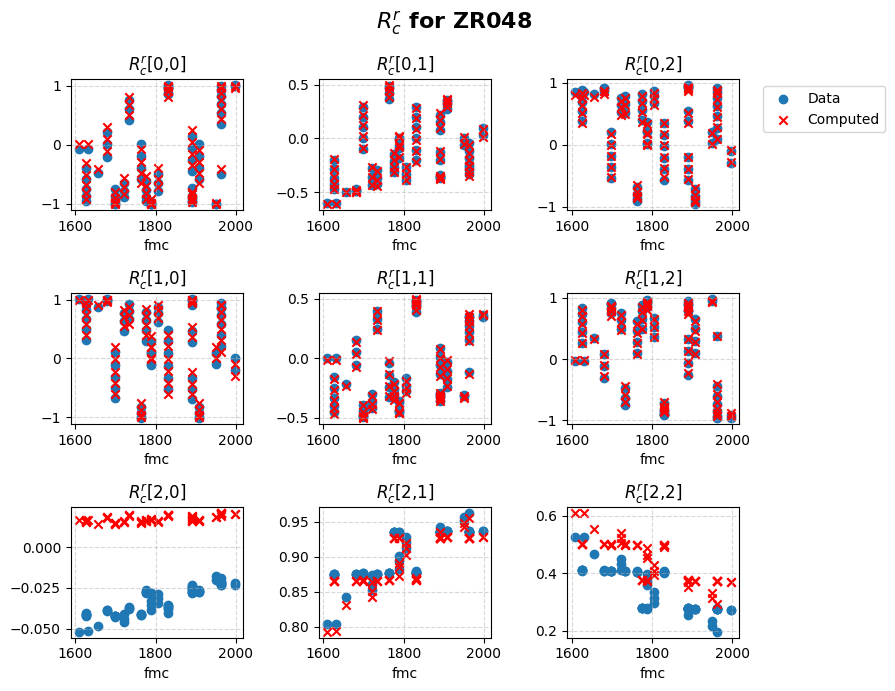

In [76]:
R_rc_data_right, R_rc_comp_right = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zr.shape[0]):
  # Compute R_mc from data assuming R_rrp values
  hr = get_H_r_data(i, zr)

  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  
 
  R_rc_data_right.append(hr @ hc_inv)
  

  # compute Hr using the median q_mc value
  R_rpm = get_R_rpm(i, zr)

  f = zr["fmc"][i]
  R_mc = R.from_quat(q_mc_median_right[f]).as_matrix()
  
  R_rc_comp_right.append(R_rrp @ R_rpm @ R_mc)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [R_mc[i][j] for R_mc in R_rc_data_right], label="Data")
    ax[i,j].scatter(zr["fmc"], [R_mc[i][j] for R_mc in R_rc_comp_right],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$R^r_c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$R^r_c$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

Plot the fits for $H^r$

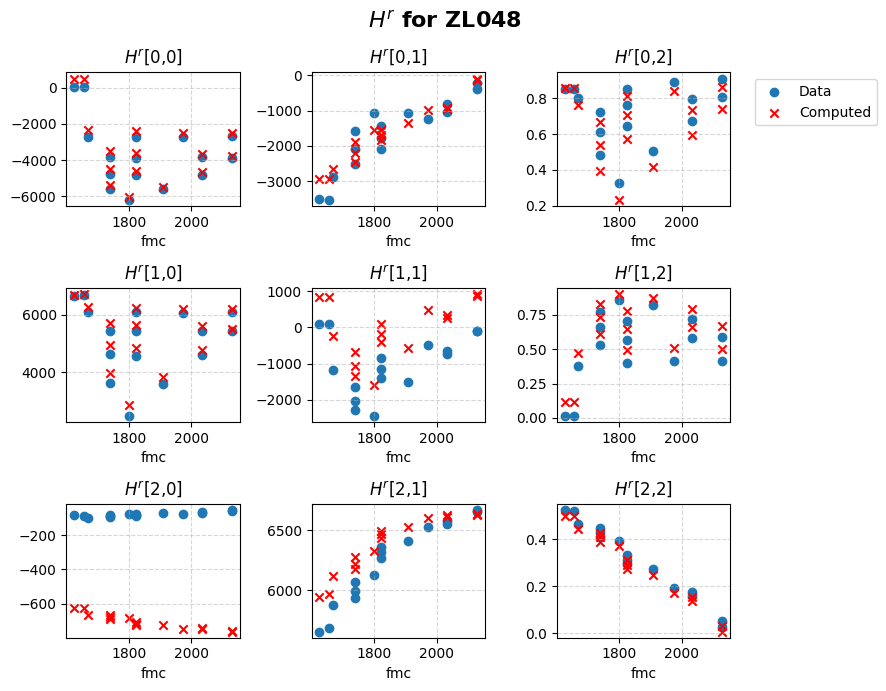

In [65]:
hr_data_left, hr_comp_left = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zl.shape[0]):
  # Parse the Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hr using the median q_mc value
  R_rpm = get_R_rpm(i, zl)

  f = zl["fmc"][i]
  R_mc = R.from_quat(q_mc_median_left[f]).as_matrix()

  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
  
  hr_comp = R_rrp @ R_rpm @ R_mc @ hc
  hr_comp_left.append(hr_comp)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [hr[i][j] for hr in hr_data_left], label="Data")
    ax[i,j].scatter(zl["fmc"], [hr[i][j] for hr in hr_comp_left],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^r$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()


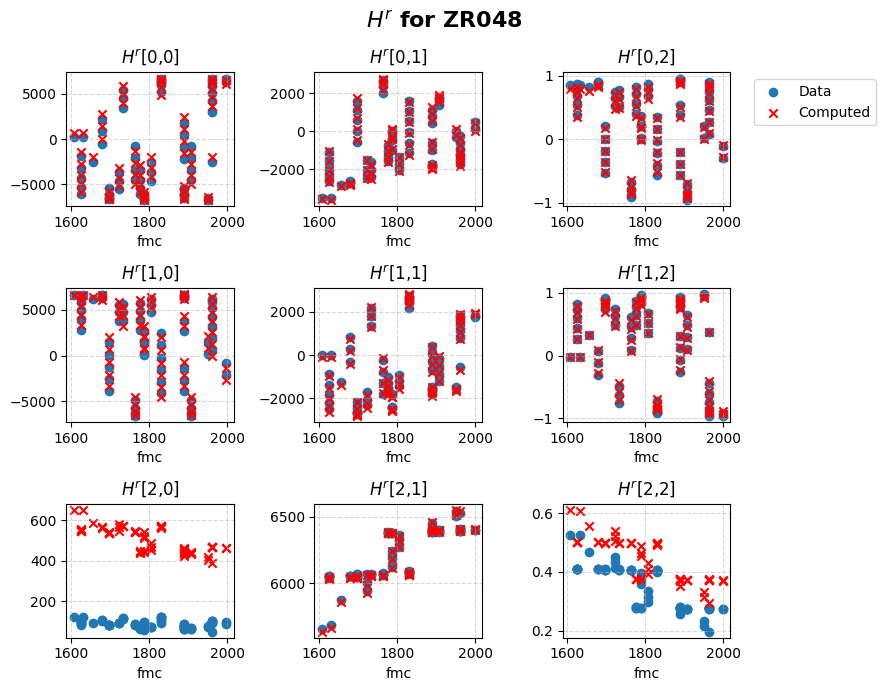

In [68]:
hr_data_right, hr_comp_right = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zr.shape[0]):
  # Parse the Hr from data
  hr_data_right.append(get_H_r_data(i, zr))

  # compute Hr using the median q_mc value
  R_rpm = get_R_rpm(i, zr)

  f = zr["fmc"][i]
  R_mc = R.from_quat(q_mc_median_right[f]).as_matrix()

  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
  
  hr_comp = R_rrp @ R_rpm @ R_mc @ hc
  hr_comp_right.append(hr_comp)

fig, ax = plt.subplots(3,3, figsize=(9,7))
for i in range(3):  
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [hr[i][j] for hr in hr_data_right], label="Data")
    ax[i,j].scatter(zr["fmc"], [hr[i][j] for hr in hr_comp_right],
                     label="Computed", marker="x", color="red")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^r$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()
